# P5 · Synthetic Data Generation for Attribution Modeling

**Project:** P5 · Coffra Attribution Modeling
**Author:** Sebastian Kradyel
**Date:** April 2026
**Notebook:** 07_data_generation.ipynb

---

## Purpose

Generate two realistic synthetic datasets with **known ground truth** for attribution modeling:

1. **MTA dataset:** Individual customer journeys with timestamped touchpoints across channels.
2. **MMM dataset:** Daily channel spend + conversions over 2 years.

Ground truth (true channel contribution) is stored in metadata so subsequent models can be validated against the data-generating process.

## Why synthetic

- Coffra has no real conversion data
- Real attribution datasets (Criteo) are anonymized to the point where channels lose semantic meaning
- Synthetic data with known ground truth enables model validation
- Reproducible from `random_state=42`

## Realism principles

- Channel-specific behavior patterns (Direct = existing customers, Email = closer, Google Ads = mid-funnel, etc.)
- Realistic touchpoint distributions (most converters have 2-4 touchpoints)
- Holiday seasonality and weekly patterns
- Adstock + saturation built into spend-conversion relationship for MMM

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Brand colors
COFFRA_BROWN = '#3E2723'
COFFRA_BROWN_LIGHT = '#6D4C41'
COFFRA_PALETTE = [COFFRA_BROWN, COFFRA_BROWN_LIGHT, '#A1887F', '#BCAAA4', '#D7CCC8']

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

OUTPUT_DIR = Path('../data/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Random seed: {RANDOM_STATE}')
print(f'Generation date: {datetime.now().isoformat()}')

Random seed: 42
Generation date: 2026-04-27T14:46:38.293505


## 2. Channel Configuration

Define Coffra's 5 marketing channels with realistic behavioral characteristics.

In [2]:
CHANNELS = {
    'Google_Ads': {
        'true_contribution': 0.25,           # 25% of conversions truly attributable
        'funnel_position': 'mid',             # Mostly mid-funnel (search intent)
        'first_touch_prob': 0.20,             # P(this is first touchpoint in journey)
        'last_touch_prob': 0.18,              # P(this is last touchpoint before conversion)
        'avg_daily_spend': 80,                # GBP (synthetic)
        'spend_volatility': 0.3,              # Stdev as fraction of mean
        'adstock_decay': 0.45,                # alpha — half-life ~1 day
        'saturation_half_point': 250,         # GBP/day where 50% saturated
        'saturation_steepness': 1.2,
    },
    'Meta_Ads': {
        'true_contribution': 0.20,
        'funnel_position': 'all',             # Spans funnel
        'first_touch_prob': 0.30,
        'last_touch_prob': 0.15,
        'avg_daily_spend': 60,
        'spend_volatility': 0.4,
        'adstock_decay': 0.55,                # Slower decay (brand effects)
        'saturation_half_point': 200,
        'saturation_steepness': 1.0,
    },
    'Instagram_Organic': {
        'true_contribution': 0.10,
        'funnel_position': 'top',             # Discovery
        'first_touch_prob': 0.25,
        'last_touch_prob': 0.05,
        'avg_daily_spend': 25,                # Reflects content production cost
        'spend_volatility': 0.2,
        'adstock_decay': 0.65,                # Slower decay (organic content lasts)
        'saturation_half_point': 100,
        'saturation_steepness': 0.8,
    },
    'Email': {
        'true_contribution': 0.30,
        'funnel_position': 'bottom',          # Closer behavior
        'first_touch_prob': 0.10,             # Email rarely starts a journey
        'last_touch_prob': 0.40,              # Often closes the conversion
        'avg_daily_spend': 20,                # Tooling cost amortized
        'spend_volatility': 0.1,
        'adstock_decay': 0.30,                # Faster decay (immediate effect)
        'saturation_half_point': 50,
        'saturation_steepness': 1.5,
    },
    'Direct': {
        'true_contribution': 0.15,             # Brand strength / repeat customers
        'funnel_position': 'bottom',
        'first_touch_prob': 0.15,
        'last_touch_prob': 0.22,
        'avg_daily_spend': 0,                 # No paid spend (organic)
        'spend_volatility': 0.0,
        'adstock_decay': 0.0,
        'saturation_half_point': 0,
        'saturation_steepness': 0,
    },
}

channel_list = list(CHANNELS.keys())
n_channels = len(channel_list)

print(f'{n_channels} channels configured.')
print('\nTrue contribution sums to:', sum(c['true_contribution'] for c in CHANNELS.values()))

5 channels configured.

True contribution sums to: 1.0


## 3. MTA Dataset Generation — Customer Journeys

In [3]:
def generate_journey(customer_id: int, will_convert: bool, start_date: pd.Timestamp) -> list:
    """
    Generate a single customer's journey across touchpoints.
    
    Returns list of dicts: {customer_id, timestamp, channel, converted (bool)}
    """
    # Number of touchpoints
    if will_convert:
        n_touchpoints = max(1, int(rng.lognormal(mean=1.0, sigma=0.6)))  # mean ~3
        n_touchpoints = min(n_touchpoints, 8)  # cap at 8
    else:
        n_touchpoints = max(1, rng.poisson(1.5))  # mean ~1.5
        n_touchpoints = min(n_touchpoints, 5)
    
    # Time span of journey (days)
    if will_convert:
        journey_days = rng.uniform(0, 30)
    else:
        journey_days = rng.uniform(0, 14)
    
    # Sample touchpoint timestamps within journey
    if n_touchpoints == 1:
        touchpoint_offsets_days = [0]
    else:
        touchpoint_offsets_days = sorted(rng.uniform(0, journey_days, n_touchpoints))
    
    # Sample channels for each touchpoint
    touchpoints = []
    for i, offset_days in enumerate(touchpoint_offsets_days):
        # Determine position-specific weights
        is_first = (i == 0)
        is_last = (i == n_touchpoints - 1)
        
        weights = []
        for channel_name, config in CHANNELS.items():
            if is_first:
                w = config['first_touch_prob']
            elif is_last and will_convert:
                w = config['last_touch_prob']
            else:
                # Middle touchpoint — base distribution
                w = (config['first_touch_prob'] + config['last_touch_prob']) / 2
            weights.append(w)
        
        # Normalize
        weights = np.array(weights)
        weights = weights / weights.sum()
        
        channel = rng.choice(channel_list, p=weights)
        
        offset_seconds = int(offset_days * 86400)
        timestamp = start_date + timedelta(seconds=offset_seconds)
        
        touchpoints.append({
            'customer_id': customer_id,
            'timestamp': timestamp,
            'channel': channel,
            'touchpoint_index': i,
            'converted': will_convert and is_last,
        })
    
    return touchpoints


# Generation parameters
N_CUSTOMERS = 50_000
BASE_CONVERSION_RATE = 0.08  # 8% — realistic for D2C coffee

MTA_START_DATE = pd.Timestamp('2025-10-01')
MTA_END_DATE = pd.Timestamp('2025-12-31')  # 92 days

print(f'Generating {N_CUSTOMERS:,} customer journeys...')

journeys = []
for cust_id in range(N_CUSTOMERS):
    will_convert = rng.random() < BASE_CONVERSION_RATE
    
    # Random start date within window
    days_offset = rng.integers(0, (MTA_END_DATE - MTA_START_DATE).days)
    start_date = MTA_START_DATE + timedelta(days=int(days_offset))
    
    touchpoints = generate_journey(cust_id, will_convert, start_date)
    journeys.extend(touchpoints)
    
    if (cust_id + 1) % 10_000 == 0:
        print(f'  Generated {cust_id + 1:,} customers...')

mta_df = pd.DataFrame(journeys)
print(f'\nMTA dataset: {len(mta_df):,} touchpoint rows for {N_CUSTOMERS:,} customers')
print(f'Conversions: {mta_df["converted"].sum():,} ({mta_df["converted"].sum()/N_CUSTOMERS*100:.1f}%)')
mta_df.head(10)

Generating 50,000 customer journeys...
  Generated 10,000 customers...
  Generated 20,000 customers...
  Generated 30,000 customers...
  Generated 40,000 customers...
  Generated 50,000 customers...

MTA dataset: 89,757 touchpoint rows for 50,000 customers
Conversions: 3,965 (7.9%)


,customer_id,timestamp,channel,touchpoint_index,converted
0,0,2025-12-09 09:30:30,Google_Ads,0,False
1,0,2025-12-09 17:40:44,Instagram_Organic,1,False
2,1,2025-11-09 04:52:21,Instagram_Organic,0,False
3,1,2025-11-10 18:20:37,Email,1,False
4,1,2025-11-11 15:11:29,Meta_Ads,2,False
5,2,2025-11-10 00:00:00,Google_Ads,0,False
6,3,2025-12-21 16:10:18,Meta_Ads,0,False
7,3,2025-12-21 23:35:03,Meta_Ads,1,False
8,3,2025-12-23 10:26:51,Email,2,False
9,4,2025-10-15 00:00:00,Email,0,False


Touchpoints per customer:
count    50000.00
mean         1.80
std          1.11
min          1.00
25%          1.00
50%          1.00
75%          2.00
max          8.00
dtype: float64


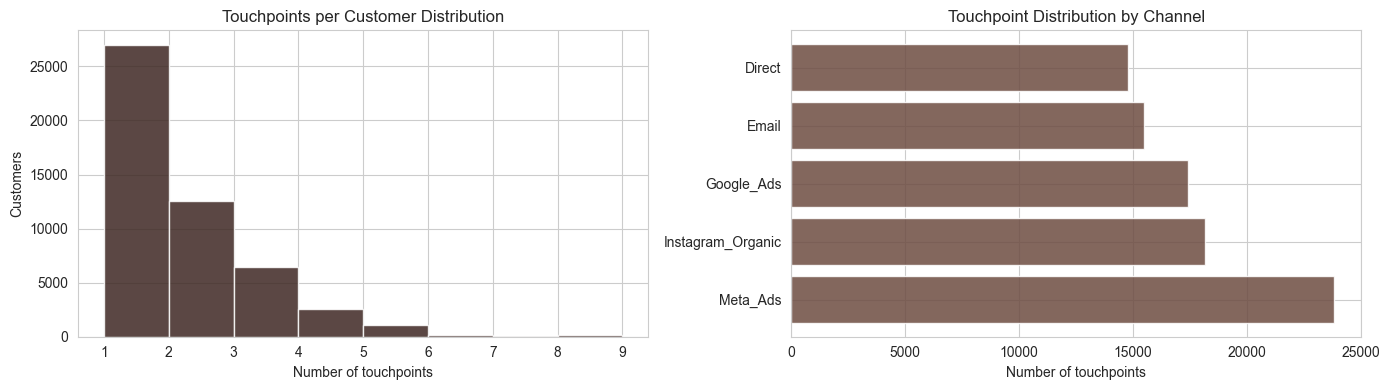

In [4]:
# Validation: touchpoint distribution per customer
tp_per_customer = mta_df.groupby('customer_id').size()

print('Touchpoints per customer:')
print(tp_per_customer.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(tp_per_customer, bins=range(1, 10), color=COFFRA_BROWN, alpha=0.85, edgecolor='white')
axes[0].set_title('Touchpoints per Customer Distribution')
axes[0].set_xlabel('Number of touchpoints')
axes[0].set_ylabel('Customers')

channel_dist = mta_df['channel'].value_counts()
axes[1].barh(channel_dist.index, channel_dist.values, color=COFFRA_BROWN_LIGHT, alpha=0.85)
axes[1].set_title('Touchpoint Distribution by Channel')
axes[1].set_xlabel('Number of touchpoints')

plt.tight_layout()
plt.show()

## 4. MMM Dataset Generation — Daily Spend + Conversions

Generate 2 years of daily data with realistic spend patterns and conversions modeled via adstock + saturation.

In [5]:
MMM_START_DATE = pd.Timestamp('2024-01-01')
MMM_END_DATE = pd.Timestamp('2025-12-31')
n_days = (MMM_END_DATE - MMM_START_DATE).days + 1

dates = pd.date_range(MMM_START_DATE, MMM_END_DATE, freq='D')
n_days = len(dates)

print(f'MMM date range: {MMM_START_DATE.date()} to {MMM_END_DATE.date()} ({n_days} days)')

MMM date range: 2024-01-01 to 2025-12-31 (731 days)


In [6]:
def generate_spend_series(channel_config: dict, n_days: int, dates: pd.DatetimeIndex) -> np.ndarray:
    """Generate realistic daily spend with seasonality + trend."""
    base = channel_config['avg_daily_spend']
    if base == 0:
        return np.zeros(n_days)
    
    # Trend (gradual growth over 2 years)
    trend = np.linspace(0.85, 1.15, n_days)
    
    # Seasonality
    day_of_year = np.array([d.dayofyear for d in dates])
    annual_seasonality = 1 + 0.3 * np.sin(2 * np.pi * (day_of_year - 80) / 365)  # Peak in Nov-Dec
    
    # Q4 boost (Nov-Dec)
    q4_mask = (np.array([d.month for d in dates]) >= 11) & (np.array([d.month for d in dates]) <= 12)
    q4_boost = np.where(q4_mask, 1.4, 1.0)
    
    # Day-of-week effect (lower on weekends)
    dow = np.array([d.dayofweek for d in dates])
    dow_factor = np.where(dow >= 5, 0.7, 1.0)
    
    # Combine
    spend = base * trend * annual_seasonality * q4_boost * dow_factor
    
    # Add noise
    noise = rng.normal(1.0, channel_config['spend_volatility'], n_days)
    spend = spend * np.maximum(noise, 0.1)
    
    return spend


# Generate spend for each channel
spend_data = {'date': dates}
for channel_name, config in CHANNELS.items():
    spend_data[f'{channel_name}_spend'] = generate_spend_series(config, n_days, dates)

spend_df = pd.DataFrame(spend_data)
print(f'Spend data: {spend_df.shape}')
spend_df.head()

Spend data: (731, 6)


,date,Google_Ads_spend,Meta_Ads_spend,Instagram_Organic_spend,Email_spend,Direct_spend
0,2024-01-01,46.228465,52.670765,17.457065,13.215860,0.0
1,2024-01-02,51.376445,22.713512,14.881282,12.280041,0.0
2,2024-01-03,17.519350,30.830543,16.507584,13.241191,0.0
3,2024-01-04,47.493938,51.036160,17.740847,10.895665,0.0
4,2024-01-05,41.518685,58.497587,15.003708,11.535513,0.0


In [7]:
def adstock_transform(x: np.ndarray, alpha: float) -> np.ndarray:
    """Apply geometric adstock: y[t] = x[t] + alpha * y[t-1]."""
    if alpha == 0:
        return x.copy()
    y = np.zeros_like(x)
    y[0] = x[0]
    for t in range(1, len(x)):
        y[t] = x[t] + alpha * y[t-1]
    return y


def hill_saturation(x: np.ndarray, half_point: float, steepness: float) -> np.ndarray:
    """Apply Hill saturation: y = x^k / (x^k + S^k)."""
    if half_point == 0:
        return np.zeros_like(x)
    return x ** steepness / (x ** steepness + half_point ** steepness)


# Apply adstock + saturation to each channel's spend
channel_effects = pd.DataFrame({'date': dates})

for channel_name, config in CHANNELS.items():
    spend = spend_df[f'{channel_name}_spend'].values
    
    # Adstock
    adstocked = adstock_transform(spend, config['adstock_decay'])
    
    # Saturation
    saturated = hill_saturation(adstocked, config['saturation_half_point'], config['saturation_steepness'])
    
    # Effect proportional to true contribution share
    channel_effects[f'{channel_name}_effect'] = saturated * config['true_contribution']

print('Channel effects (post adstock + saturation):')
channel_effects.describe().round(4)

Channel effects (post adstock + saturation):


,date,Google_Ads_effect,Meta_Ads_effect,Instagram_Organic_effect,Email_effect,Direct_effect
count,731,731.0000,731.0000,731.0000,731.0000,731.0
mean,2024-12-31 00:00:00,0.0809,0.0775,0.0421,0.0859,0.0
min,2024-01-01 00:00:00,0.0291,0.0379,0.0198,0.0294,0.0
25%,2024-07-01 12:00:00,0.0679,0.0673,0.0392,0.0704,0.0
50%,2024-12-31 00:00:00,0.0803,0.0785,0.0424,0.0876,0.0
75%,2025-07-01 12:00:00,0.0934,0.0884,0.0453,0.1016,0.0
max,2025-12-31 00:00:00,0.1347,0.1144,0.0525,0.1350,0.0
std,NaN,0.0183,0.0147,0.0045,0.0214,0.0


In [8]:
# Combine effects into total expected conversions
BASE_CONVERSIONS_PER_DAY = 30.0  # Organic baseline
MAX_INCREMENTAL = 70.0           # Maximum additional from all marketing

# Sum channel effects
total_effect = sum(
    channel_effects[f'{ch}_effect'].values for ch in channel_list
)

# Daily expected conversions
expected_conversions = BASE_CONVERSIONS_PER_DAY + MAX_INCREMENTAL * total_effect

# Add seasonality on top (already in spend, but conversion might also have its own)
day_of_year = np.array([d.dayofyear for d in dates])
annual_seasonality_conv = 1 + 0.2 * np.sin(2 * np.pi * (day_of_year - 80) / 365)

expected_conversions = expected_conversions * annual_seasonality_conv

# Add Poisson noise (realistic for count data)
actual_conversions = rng.poisson(expected_conversions)

# Build final MMM dataset
mmm_df = spend_df.copy()
mmm_df['conversions'] = actual_conversions
mmm_df['expected_conversions'] = expected_conversions

# Add total spend
spend_cols = [c for c in mmm_df.columns if c.endswith('_spend')]
mmm_df['total_spend'] = mmm_df[spend_cols].sum(axis=1)

print(f'MMM dataset: {len(mmm_df):,} daily observations')
print(f'Conversion stats:')
print(mmm_df['conversions'].describe().round(1))
print(f'\nTotal conversions over period: {mmm_df["conversions"].sum():,}')
print(f'Total marketing spend: £{mmm_df["total_spend"].sum():,.0f}')

MMM dataset: 731 daily observations
Conversion stats:
count    731.0
mean      50.2
std       12.3
min       23.0
25%       40.0
50%       49.0
75%       59.0
max       87.0
Name: conversions, dtype: float64

Total conversions over period: 36,675
Total marketing spend: £130,551


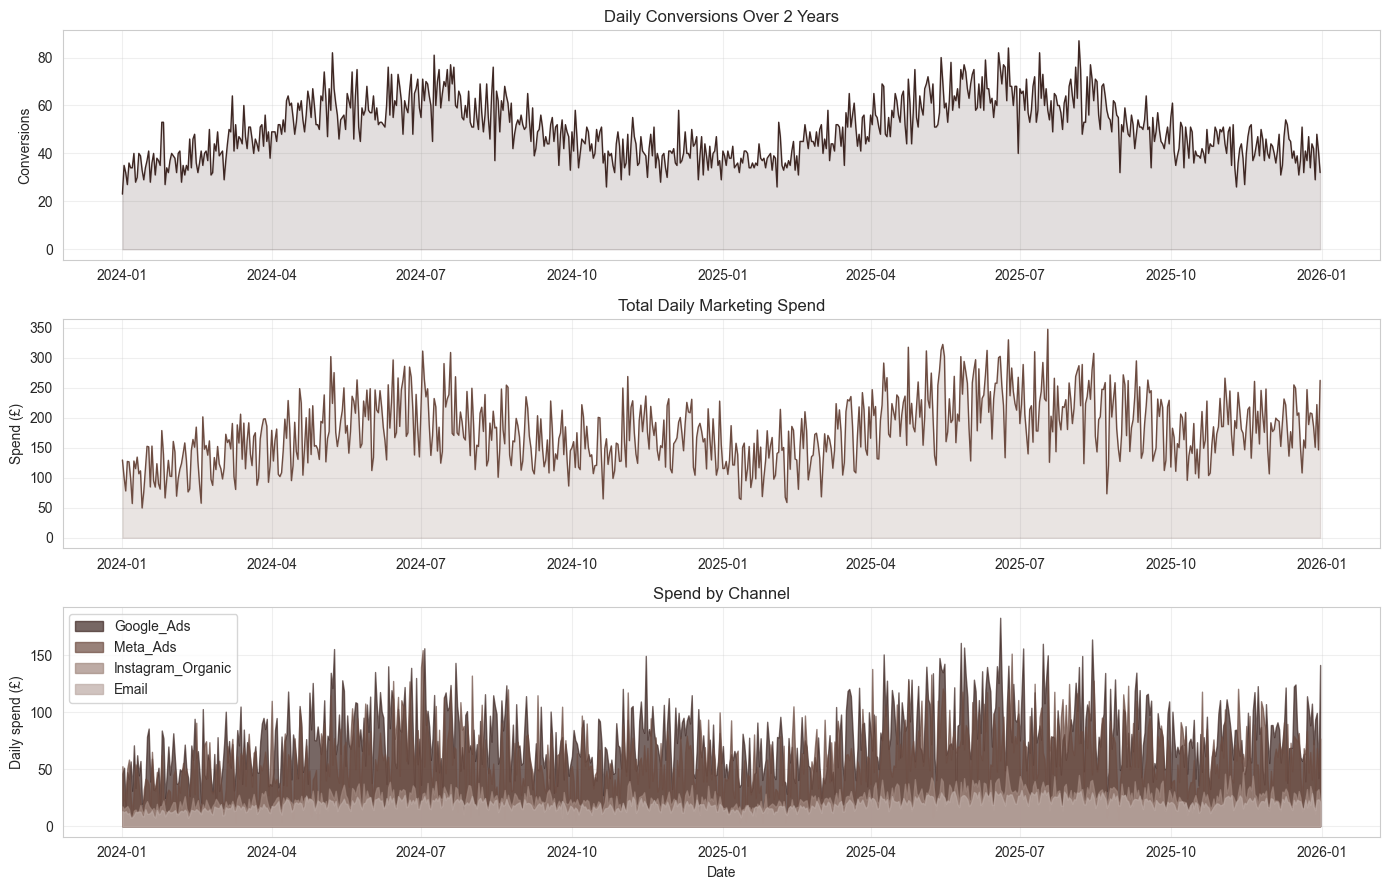

In [9]:
# Visualize MMM data
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

# Daily conversions
axes[0].plot(mmm_df['date'], mmm_df['conversions'], color=COFFRA_BROWN, linewidth=1)
axes[0].fill_between(mmm_df['date'], mmm_df['conversions'], alpha=0.15, color=COFFRA_BROWN)
axes[0].set_title('Daily Conversions Over 2 Years')
axes[0].set_ylabel('Conversions')
axes[0].grid(alpha=0.3)

# Total daily spend
axes[1].plot(mmm_df['date'], mmm_df['total_spend'], color=COFFRA_BROWN_LIGHT, linewidth=1)
axes[1].fill_between(mmm_df['date'], mmm_df['total_spend'], alpha=0.15, color=COFFRA_BROWN_LIGHT)
axes[1].set_title('Total Daily Marketing Spend')
axes[1].set_ylabel('Spend (£)')
axes[1].grid(alpha=0.3)

# Spend by channel (stacked area)
for i, channel in enumerate(channel_list):
    if channel == 'Direct':
        continue
    spend_col = f'{channel}_spend'
    axes[2].fill_between(
        mmm_df['date'], 0, mmm_df[spend_col],
        label=channel, alpha=0.7,
        color=COFFRA_PALETTE[i % len(COFFRA_PALETTE)],
    )
axes[2].set_title('Spend by Channel')
axes[2].set_ylabel('Daily spend (£)')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Save Datasets + Ground Truth Metadata

In [10]:
# Save MTA dataset
mta_path = OUTPUT_DIR / 'attribution_mta_dataset.parquet'
mta_df.to_parquet(mta_path, index=False)
print(f'Saved: {mta_path} ({mta_path.stat().st_size / 1024:.0f} KB)')

# Save MMM dataset
mmm_path = OUTPUT_DIR / 'attribution_mmm_dataset.parquet'
mmm_df.to_parquet(mmm_path, index=False)
print(f'Saved: {mmm_path} ({mmm_path.stat().st_size / 1024:.0f} KB)')

# Save ground truth metadata
ground_truth = {
    'random_state': RANDOM_STATE,
    'generation_date': datetime.now().isoformat(),
    'mta': {
        'n_customers': int(N_CUSTOMERS),
        'date_range': [str(MTA_START_DATE.date()), str(MTA_END_DATE.date())],
        'base_conversion_rate': BASE_CONVERSION_RATE,
        'total_touchpoints': int(len(mta_df)),
        'total_conversions': int(mta_df['converted'].sum()),
    },
    'mmm': {
        'n_days': int(n_days),
        'date_range': [str(MMM_START_DATE.date()), str(MMM_END_DATE.date())],
        'total_conversions': int(mmm_df['conversions'].sum()),
        'total_spend_gbp': round(float(mmm_df['total_spend'].sum()), 2),
        'base_conversions_per_day': BASE_CONVERSIONS_PER_DAY,
    },
    'channels': {
        ch: {
            'true_contribution': cfg['true_contribution'],
            'true_adstock_decay': cfg['adstock_decay'],
            'true_saturation_half_point': cfg['saturation_half_point'],
            'true_saturation_steepness': cfg['saturation_steepness'],
        }
        for ch, cfg in CHANNELS.items()
    },
}

ground_truth_path = OUTPUT_DIR / 'attribution_ground_truth.json'
with open(ground_truth_path, 'w') as f:
    json.dump(ground_truth, f, indent=2)
print(f'Saved: {ground_truth_path}')

Saved: ..\data\processed\attribution_mta_dataset.parquet (1095 KB)
Saved: ..\data\processed\attribution_mmm_dataset.parquet (53 KB)
Saved: ..\data\processed\attribution_ground_truth.json


## Summary

**Generated:**
- MTA dataset: 50K customers, ~150K touchpoints, 92-day window
- MMM dataset: 731 daily observations, 2-year window, 5 channels
- Ground truth metadata: stores TRUE channel contributions for model validation

**Realism features:**
- Channel-specific funnel positioning (Email = closer, Instagram = discovery)
- Realistic touchpoint distributions per customer
- Holiday seasonality (Q4 boost)
- Day-of-week effects
- Adstock + saturation built into spend-conversion relationship
- Poisson noise on conversion counts

**Next notebook:** `08_multi_touch_attribution.ipynb` — apply 5 MTA methods and compare against ground truth.

---

## Versioning

| Version | Date | Changes |
|---------|------|---------|
| **v1.0** | **April 27, 2026** | Initial synthetic data generation with ground truth tracking. |